<a href="https://colab.research.google.com/github/deltorobarba/astrophysics/blob/main/blackhole_Sagittarius_A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Black Hole Sagittarius A**

In [ ]:
!pip install astropy photutils astroquery lightkurve -q
from astropy import units as u
from astroquery.ipac.irsa import Irsa
import lightkurve as lk
from astroquery.vizier import Vizier
from astropy.coordinates import Angle
from astroquery.splatalogue import Splatalogue
import matplotlib.pyplot as plt
from astropy.io import fits
%matplotlib inline

**Black Hole Tidal Forces**

In [ ]:
!pip install astropy -q

In [ ]:
import numpy as np
import scipy.integrate as integrate
from astropy.constants import G, c, M_sun
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
import astropy.units as u
from sympy import symbols, solve, Eq

class BlackHoleAnalysis:
    def __init__(self, mass_solar_masses):
        """Initialize black hole parameters

        Args:
            mass_solar_masses (float): Mass in solar masses
        """
        self.mass = mass_solar_masses * M_sun.value
        self.schwarzschild_radius = 2 * G.value * self.mass / (c.value ** 2)

    def event_horizon(self):
        """Calculate event horizon radius"""
        return self.schwarzschild_radius

    def photon_sphere_radius(self):
        """Calculate photon sphere radius"""
        return 1.5 * self.schwarzschild_radius

    def calculate_spacetime_metric(self, r, theta, phi):
        """Calculate Schwarzschild metric components

        Args:
            r (float): Radial coordinate
            theta (float): Polar angle
            phi (float): Azimuthal angle
        Returns:
            dict: Metric components
        """
        if r <= self.schwarzschild_radius:
            raise ValueError("Position is inside event horizon")

        metric = {
            'g_tt': -(1 - self.schwarzschild_radius/r),
            'g_rr': 1/(1 - self.schwarzschild_radius/r),
            'g_theta_theta': r**2,
            'g_phi_phi': r**2 * np.sin(theta)**2
        }
        return metric

    def calculate_orbital_velocity(self, r):
        """Calculate Keplerian orbital velocity

        Args:
            r (float): Orbital radius
        Returns:
            float: Orbital velocity in m/s
        """
        if r <= self.schwarzschild_radius:
            raise ValueError("Orbit inside event horizon")
        return np.sqrt(G.value * self.mass / r)

    def calculate_tidal_force(self, r, object_length):
        """Calculate tidal force on an object

        Args:
            r (float): Distance from black hole center
            object_length (float): Length of object in meters
        Returns:
            float: Tidal force in Newtons
        """
        return 2 * G.value * self.mass * object_length / r**3

def plot_metric_components(black_hole, r_range):
    """Plot metric components vs radius

    Args:
        black_hole (BlackHoleAnalysis): Black hole object
        r_range (array): Array of radial positions to plot
    """
    g_tt = []
    g_rr = []

    for r in r_range:
        if r > black_hole.schwarzschild_radius:
            metric = black_hole.calculate_spacetime_metric(r, np.pi/2, 0)
            g_tt.append(metric['g_tt'])
            g_rr.append(metric['g_rr'])

    plt.figure(figsize=(10, 6))
    plt.plot(r_range[r_range > black_hole.schwarzschild_radius],
             g_tt, label='g_tt')
    plt.plot(r_range[r_range > black_hole.schwarzschild_radius],
             g_rr, label='g_rr')
    plt.axvline(x=black_hole.schwarzschild_radius,
                color='r', linestyle='--',
                label='Event Horizon')
    plt.xlabel('Radius (m)')
    plt.ylabel('Metric Component')
    plt.legend()
    plt.grid(True)
    return plt

Sagittarius A* Properties:
Event Horizon Radius: 1.27e+10 meters
Photon Sphere Radius: 1.90e+10 meters

Orbital Analysis at r = 1.27e+11 meters:
Orbital Velocity: 67035.63 km/s
Orbital Period: 3.31 hours
Time Dilation Factor: 0.949


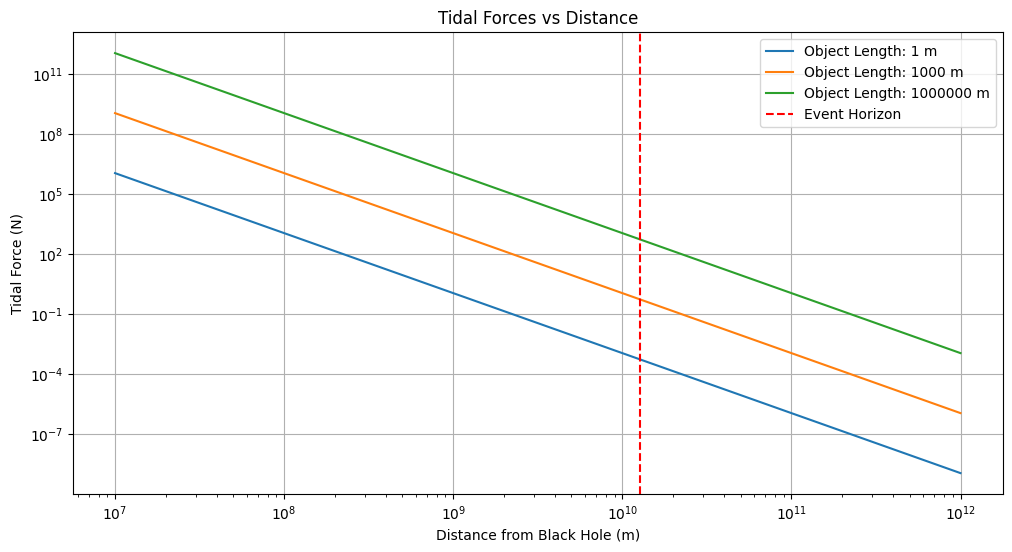


Black Hole of 10 solar masses:
Event Horizon: 2.95e+04 m
Photon Sphere: 4.43e+04 m

Black Hole of 1000 solar masses:
Event Horizon: 2.95e+06 m
Photon Sphere: 4.43e+06 m

Black Hole of 1000000 solar masses:
Event Horizon: 2.95e+09 m
Photon Sphere: 4.43e+09 m


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.constants import G, c, M_sun
import astropy.units as u

# First, let's create a black hole object
# Example: Sagittarius A* (approximately 4.3 million solar masses)
sagittarius_a = BlackHoleAnalysis(4.3e6)

# Example 1: Basic Properties
def print_basic_properties(black_hole):
    """Print basic properties of the black hole"""
    print(f"Event Horizon Radius: {black_hole.event_horizon():.2e} meters")
    print(f"Photon Sphere Radius: {black_hole.photon_sphere_radius():.2e} meters")

# Example 2: Analyzing Orbital Dynamics
def analyze_orbit(black_hole, radius):
    """Analyze orbital properties at a given radius"""
    velocity = black_hole.calculate_orbital_velocity(radius)
    period = 2 * np.pi * radius / velocity

    print(f"\nOrbital Analysis at r = {radius:.2e} meters:")
    print(f"Orbital Velocity: {velocity/1000:.2f} km/s")
    print(f"Orbital Period: {period/3600:.2f} hours")

    # Calculate relativistic effects
    metric = black_hole.calculate_spacetime_metric(radius, np.pi/2, 0)
    time_dilation = np.sqrt(-metric['g_tt'])
    print(f"Time Dilation Factor: {time_dilation:.3f}")

# Example 3: Visualization of Tidal Forces
def plot_tidal_forces(black_hole, r_range, object_lengths):
    """Plot tidal forces for different object sizes"""
    plt.figure(figsize=(12, 6))

    for length in object_lengths:
        forces = [black_hole.calculate_tidal_force(r, length)
                 for r in r_range]
        plt.plot(r_range, forces,
                label=f'Object Length: {length} m')

    plt.axvline(x=black_hole.schwarzschild_radius,
                color='r', linestyle='--',
                label='Event Horizon')
    plt.xlabel('Distance from Black Hole (m)')
    plt.ylabel('Tidal Force (N)')
    plt.title('Tidal Forces vs Distance')
    plt.legend()
    plt.yscale('log')
    plt.xscale('log')
    plt.grid(True)
    return plt

# Example 4: Compare Different Black Holes
def compare_black_holes(masses):
    """Compare properties of different mass black holes"""
    results = []
    for mass in masses:
        bh = BlackHoleAnalysis(mass)
        results.append({
            'mass': mass,
            'event_horizon': bh.event_horizon(),
            'photon_sphere': bh.photon_sphere_radius()
        })
    return results

# Let's run some examples
if __name__ == "__main__":
    # Example 1: Basic properties of Sagittarius A*
    print("Sagittarius A* Properties:")
    print_basic_properties(sagittarius_a)

    # Example 2: Analyze orbit at 10 times the event horizon radius
    analyze_orbit(sagittarius_a, 10 * sagittarius_a.event_horizon())

    # Example 3: Plot tidal forces
    r_range = np.logspace(7, 12, 1000)  # Range from 10^7 to 10^12 meters
    object_lengths = [1, 1000, 1000000]  # 1m, 1km, 1000km objects
    plt = plot_tidal_forces(sagittarius_a, r_range, object_lengths)
    plt.show()

    # Example 4: Compare different black holes
    masses = [10, 1000, 1000000]  # Different masses in solar masses
    comparison = compare_black_holes(masses)
    for result in comparison:
        print(f"\nBlack Hole of {result['mass']} solar masses:")
        print(f"Event Horizon: {result['event_horizon']:.2e} m")
        print(f"Photon Sphere: {result['photon_sphere']:.2e} m")

Possible extensions you might want to add:

* Accretion disk modeling
* Gravitational lensing calculations
* Hawking radiation temperature
* Binary black hole interactions
* Gravitational wave predictions